### Surface Runoff Susceptibility in Nisqually River Watershed Data Download

### Study Area

In [ ]:
# Import packages for working with files and folders
import os
import pathlib

# Import package for working with geospatial data
import geopandas as gpd

# Import package for working with tabular data
import pandas as pd

# Import libaray for plotting
import matplotlib.pyplot as plt

# Import library for working with scientific computation
import numpy as np

# Import library for making interactive plots with vector/tabular data
import hvplot.pandas 

# Import library for making interactive plot
import holoviews as hv

# Import for working with zip files
import zipfile

# Import for creating file folders
from pathlib import Path


In [ ]:
# Find project root (looks for README.md)
project_dir = Path.cwd()

while not (project_dir / "README.md").exists():
    if project_dir == project_dir.parent:
        raise FileNotFoundError("Could not find project root (README.md).")
    project_dir = project_dir.parent

# Define directory structure
data_dir = project_dir / "data"
raw_dir = data_dir / "raw"
processed_dir = data_dir / "processed"
notebooks_dir = project_dir / "notebooks"

# Create folders if they don't exist
raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

# Print for sanity check
print(f"Project directory: {project_dir}")
print(f"Data directory: {data_dir}")

In [ ]:


project_dir = r"C:\Users\nymve\Documents\education\earth-data-analytics\spring-surface-runoff-nisqually-final-project"

data_dir = os.path.join(project_dir, "data")

zip_path = os.path.join(data_dir, "WBD_17_HU2_GPKG.zip")

extract_dir = os.path.join(data_dir, "wbd")

os.makedirs(extract_dir, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Path to GeoPackage (after unzip)
wbd_gpkg_path = os.path.join(extract_dir, "WBD_17_HU2_GPKG.gpkg")

# Read HUC8 layer
wbd_gdf = gpd.read_file(wbd_gpkg_path, layer="WBDHU8")

print(wbd_gdf.head())

                                    tnmid  \
0  {3DB62677-1E95-4C7F-A328-2DF39761B05D}   
1  {C19C3336-0531-43B8-8DAC-569C87D4E46C}   
2  {1F9A8978-7AF6-4B64-83A8-6296AF7194FD}   
3  {31964435-132E-4924-ADF4-5D732EBE86D9}   
4  {E601469F-456B-46E2-9AD8-49049D17B6C5}   

                             metasourceid                    sourcedatadesc  \
0  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
1  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
2  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
3  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
4  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   

                                    sourceoriginator sourcefeatureid  \
0  Natural Resources and Conservation Service and...            None   
1  Natural Resources and Conservation Service and...            None   
2  Natural Resources and Conservation 

In [3]:
print(wbd_gdf.columns)

Index(['tnmid', 'metasourceid', 'sourcedatadesc', 'sourceoriginator',
       'sourcefeatureid', 'loaddate', 'referencegnis_ids', 'areaacres',
       'areasqkm', 'states', 'huc8', 'name', 'shape_Length', 'shape_Area',
       'geometry'],
      dtype='object')


In [4]:
wbd_gdf.head()

,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,shape_Length,shape_Area,geometry
0,{3DB62677-1E95-4C7F-A328-2DF39761B05D},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1158060,455018.41,1841.40,OR,17090007,Middle Willamette,NaN,NaN,"POLYGON ((-123.04359 45.38033, -123.04345 45.3..."
1,{C19C3336-0531-43B8-8DAC-569C87D4E46C},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1136527,857035.12,3468.30,OR,17090004,Mckenzie,NaN,NaN,"POLYGON ((-122.02273 44.50785, -122.02237 44.5..."
2,{1F9A8978-7AF6-4B64-83A8-6296AF7194FD},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1158060,1198333.82,4849.49,OR,17090003,Upper Willamette,NaN,NaN,"POLYGON ((-123.38229 44.90266, -123.38196 44.9..."
3,{31964435-132E-4924-ADF4-5D732EBE86D9},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1150077,666390.78,2696.79,OR,17090006,South Santiam,NaN,NaN,"POLYGON ((-122.66308 44.76978, -122.66266 44.7..."
4,{E601469F-456B-46E2-9AD8-49049D17B6C5},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,391131,571545.15,2312.96,WA,17010307,Lower Spokane,NaN,NaN,"POLYGON ((-117.9992 48.12883, -117.99877 48.12..."


In [5]:
wbd_gdf[wbd_gdf["name"].str.contains("Nisqually", case=False)]

,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,shape_Length,shape_Area,geometry
227,{AB20B6D1-23E0-4AEB-A1EC-55722FB6D0DE},{A9DB8B60-5A4A-4FFC-8BE7-FA64FC77FE78},Pierce 2020,"Pierce County Washington, Washington State Dep...",None,2024-10-30 13:39:19,1511938,492844.38,1994.47,WA,17110015,Nisqually,NaN,NaN,"MULTIPOLYGON (((-122.68186 47.09905, -122.6813..."


In [6]:
nisqually_gdf = wbd_gdf[wbd_gdf["huc8"] == "17110015"]

In [7]:
print(nisqually_gdf["name"])

227    Nisqually
Name: name, dtype: object


<Axes: >

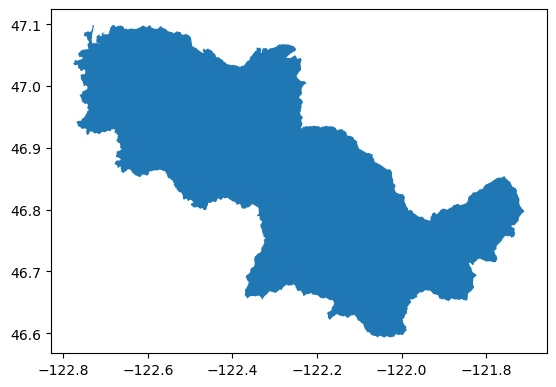

In [8]:
# Plot to see that it worked
nisqually_gdf.plot()

In [9]:
# Plot the results with web tile images
nisqually_gdf_plot = nisqually_gdf.hvplot(
    geo=True, tiles='EsriImagery',
    fill_color=None, line_color='white',
    title='Nisqually Watershed (HUC8)',
    frame_width=500,
    xlabel="Longitude",
    ylabel="Latitude")

# Display the plot with esri imagery
nisqually_gdf_plot

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

### STRM
### NRCS Soil
### NLCD Impervious Surface
### MACA Climate Data